In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

from itertools import product
from copy      import deepcopy
from time      import time

from scipy.interpolate import interp1d
from scipy.integrate   import trapz

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
#Euclid survey specifications, N_gw in [10^5-10^6] according to ET
galaxy_specs = {'fsky': 0.35, 
                'gal_per_arcmin': 30.,
                'sigma_eps': 0.3,  #sigma associated to noise for GC and WL
                'Nbin_ell': 20,
                'lmin': 4,
                'lmax': 1500}

GW_specs = {'fsky': 0.35, 
            'N_gw': 10**5, 
            'sigma_eps_gw': 0.005} #sigma associated to noise (d_L) for GW-WL

analysis_settings = {'Nbin_ell': 20,
                     'lmin': 4,
                     'lmax': 1500}

use_obs  = ['GC']


In [3]:
lmin = np.log10(analysis_settings['lmin'])
lmax = np.log10(analysis_settings['lmax'])
N    = analysis_settings['Nbin_ell']

ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])]) 

#evaluation of middle points of each bin 
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

In [4]:
#Cosmological parameters describing the LCDM Universe
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}

MG_params={'MG_flag': 0}
fiducial.update(MG_params)
camb_path = '/users/chiaradeleo/Desktop/MGCobaya/MGCAMB' 


In [5]:
distributions = {}#np.load('./mock_data/MG_test_galonly_IApoly_source_distribution.npy',allow_pickle=True).item()


dist = galaxy_distribution(survey='Euclid-10')
bin_lims = dist.galdict['bin_lims']
bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
Nbins_gc = len(bin_lims)-1

distributions['GC'] = {'dist': dist.galdict['binned_dist'],
                       'Nbins': Nbins_gc,
                       'zmean': bin_mids}
dist = galaxy_distribution(survey='Euclid-10')
bin_lims = dist.galdict['bin_lims']
bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
Nbins_wl = len(bin_lims)-1

distributions['WL'] = {'dist': dist.galdict['binned_dist'],
                       'Nbins': Nbins_wl,
                       'zmean': bin_mids}

print(bin_mids)

[0.5  1.   1.5  2.25 3.  ]


In [6]:
if 'GC' in distributions:
    Nbins_gc=distributions['GC']['Nbins']

if 'WL' in distributions:
    Nbins_wl=distributions['WL']['Nbins']
if Nbins_gc>=Nbins_wl:
    bincolors = sb.color_palette('hls',Nbins_gc)

else:
    bincolors = sb.color_palette('hls',Nbins_wl)

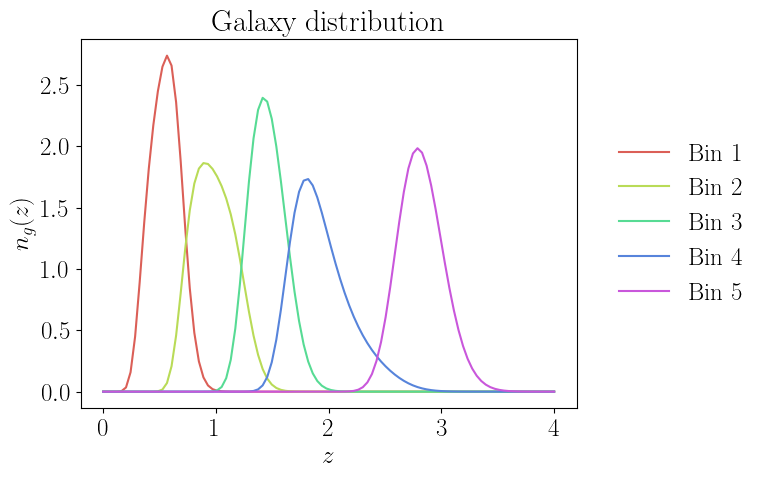

In [7]:
bincolors = sb.color_palette('hls',Nbins_gc)
zplot = np.linspace(0.001,4,100)

plt.figure()
for i in range(Nbins_gc):
    plt.plot(zplot, distributions['GC']['dist'][i](zplot),color=bincolors[i],label=r'Bin {}'.format(i+1))
plt.xlabel(r'$z$')
plt.ylabel(r'$n_g(z)$')
plt.legend(**sidelegend)
plt.title('Galaxy distribution');

In [8]:
from source_code.compute_obs_sources import get_obs
del(distributions['WL'])

In [9]:
calc_obs_density = get_obs(fiducial,distributions,ells,camb_path,case='density',feedback=True)


CAMB took 0.83 s
Cls packing took 0.00 s
Cls computed in 0.9 s


In [10]:
calc_obs_total = get_obs(fiducial,distributions,ells,camb_path,case='total',feedback=True)


CAMB took 0.83 s
Cls packing took 0.00 s
Cls computed in 0.8 s


In [11]:
calc_obs_redshift=get_obs(fiducial,distributions,ells,camb_path,case='redshift',feedback=True)


CAMB took 0.81 s
Cls packing took 0.00 s
Cls computed in 0.8 s


In [12]:
calc_obs_velocity=get_obs(fiducial,distributions,ells,camb_path,case='velocity',feedback=True)


CAMB took 0.82 s
Cls packing took 0.00 s
Cls computed in 0.8 s


In [13]:
calc_obs_lensing=get_obs(fiducial,distributions,ells,camb_path,case='lensing',feedback=True)


CAMB took 0.77 s
Cls packing took 0.00 s
Cls computed in 0.8 s


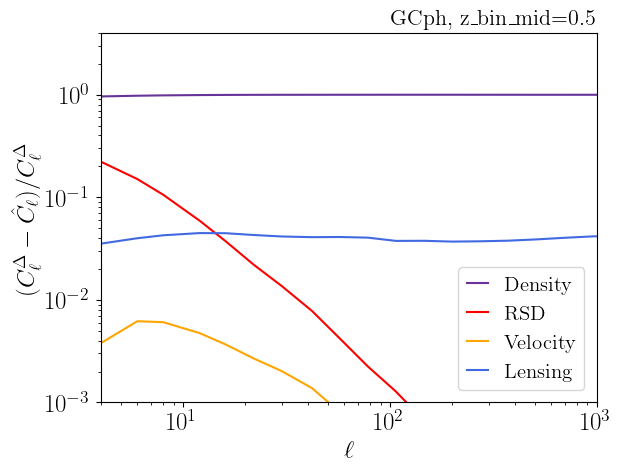

In [29]:
 norm = ells*(ells+1)/(2*np.pi)
sidelegend = {'bbox_to_anchor': (0.7,0.2), 
              'loc': "center left",
              'frameon': True,
             'fontsize': 'small',   # Adjusting font size
            'handlelength': 1,     # Adjusting handle length
            'markerscale': 0.8     # Adjusting marker scale
}

i=1
plt.title('GCph, z_bin_mid=0.5',loc='right',fontdict={'fontsize':16})
plt.plot(ells,np.abs(-calc_obs_density.Cls['G{}xG{}'.format(i,i)]+calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Density'.format(i),color='rebeccapurple')
plt.plot(ells,np.abs(-calc_obs_redshift.Cls['G{}xG{}'.format(i,i)]+calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'RSD'.format(i),color='red')
plt.plot(ells,np.abs(calc_obs_velocity.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Velocity'.format(i),color='orange')
plt.plot(ells,np.abs(calc_obs_lensing.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Lensing'.format(i),color='royalblue')
        #print(calc_obs_lensing.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])
plt.xlabel(r'$\ell$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xscale('log')
plt.yscale('log')
    
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-3,4)
plt.xlim(4,1e3)
plt.ylabel(r'$(C_\ell^{\Delta}-\hat{C_\ell})/C_\ell^{\Delta}$')
plt.legend(**sidelegend)
plt.show()

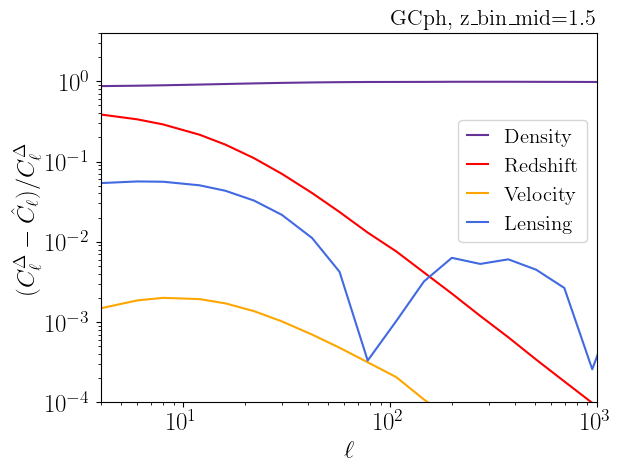

In [27]:
norm = ells*(ells+1)/(2*np.pi)
sidelegend = {'bbox_to_anchor': (0.7,0.6), 
              'loc': "center left",
              'frameon': True,
             'fontsize': 'small',   # Adjusting font size
            'handlelength': 1,     # Adjusting handle length
            'markerscale': 0.8     # Adjusting marker scale
}

i=3
plt.title('GCph, z_bin_mid=1.5',loc='right',fontdict={'fontsize':16})
plt.plot(ells,np.abs(-calc_obs_density.Cls['G{}xG{}'.format(i,i)]+calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Density'.format(i),color='rebeccapurple')
plt.plot(ells,np.abs(-calc_obs_redshift.Cls['G{}xG{}'.format(i,i)]+calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Redshift'.format(i),color='red')
plt.plot(ells,np.abs(calc_obs_velocity.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Velocity'.format(i),color='orange')
plt.plot(ells,np.abs(calc_obs_lensing.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Lensing'.format(i),color='royalblue')
        #print(calc_obs_lensing.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])
plt.xlabel(r'$\ell$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xscale('log')
plt.yscale('log')
    
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-4,4)
plt.xlim(4,1e3)
plt.ylabel(r'$(C_\ell^{\Delta}-\hat{C_\ell})/C_\ell^{\Delta}$')
plt.legend(**sidelegend)
plt.show()

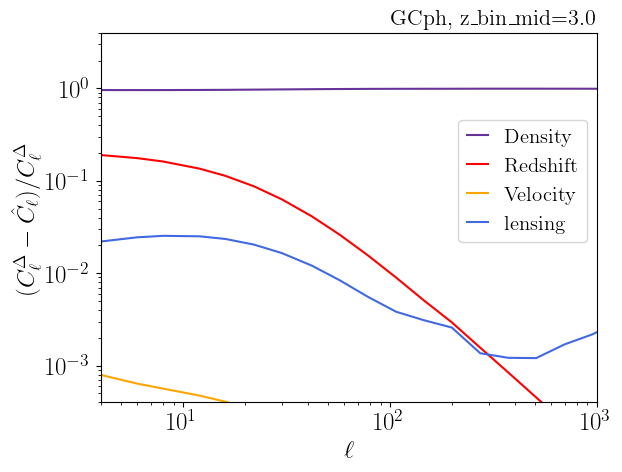

In [23]:
sidelegend = {'bbox_to_anchor': (0.7,0.6), 
              'loc': "center left",
              'frameon': True,
             'fontsize': 'small',   # Adjusting font size
            'handlelength': 1,     # Adjusting handle length
            'markerscale': 0.8     # Adjusting marker scale
}
i=5
plt.title('GCph, z_bin_mid=3.0',loc='right',fontdict={'fontsize':16})
plt.plot(ells,np.abs(-calc_obs_density.Cls['G{}xG{}'.format(i,i)]+calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Density'.format(i),color='rebeccapurple')
plt.plot(ells,np.abs(-calc_obs_redshift.Cls['G{}xG{}'.format(i,i)]+calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Redshift'.format(i),color='red')
plt.plot(ells,np.abs(calc_obs_velocity.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'Velocity'.format(i),color='orange')
plt.plot(ells,np.abs(calc_obs_lensing.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])/calc_obs_total.Cls['G{}xG{}'.format(i,i)],
                         label=r'lensing'.format(i),color='royalblue')
        #print(calc_obs_lensing.Cls['G{}xG{}'.format(i,i)]-calc_obs_total.Cls['G{}xG{}'.format(i,i)])
plt.xlabel(r'$\ell$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xscale('log')
plt.yscale('log')
    
plt.xscale('log')
plt.yscale('log')
plt.ylim(4e-4,4)
plt.xlim(4,1e3)
plt.ylabel(r'$(C_\ell^{\Delta}-\hat{C_\ell})/C_\ell^{\Delta}$')
plt.legend(**sidelegend)
plt.show()